In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from src.config import colors, get_birth_values, TIFF_DPI
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan


sns.set_theme(style="whitegrid")


In [9]:
# configure pandas to avoid truncating DataFrame outputs

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)



In [10]:
df = pd.read_csv('data/dataset_mrh_0.9.csv')
df.head()


,Species,Parameter,DAF,Reference,Obs,Quote,DOI,link,Cluster,Data_curator,GA(H+14)
0,Mouse,GE volume peak,15.75,"Charvet et al., 2017",NaN,"""The GE peak size occurs between the ages of E...",https://doi.org/10.1098/rspb.2017.1169,NaN,Brain,Cottam 2024,NaN
1,Mouse,Cortical proliferative zone volume peak,15.00,"Charvet et al., 2017",NaN,"""The peak size of the CPP occurs between ED 14...",https://doi.org/10.1098/rspb.2017.1169,NaN,Brain,Cottam 2024,NaN
2,Human,GE volume peak,154.00,"Charvet et al., 2017",NaN,"""The GE peak size occurs between the ages of E...",https://doi.org/10.1098/rspb.2017.1169,NaN,Brain,Cottam 2024,168.0
3,Human,Cortical proliferative zone volume peak,168.00,"Charvet et al., 2017",NaN,"""The peak size of the CPP occurs between ED 14...",https://doi.org/10.1098/rspb.2017.1169,NaN,Brain,Cottam 2024,182.0
4,Mouse,Corpus callosum peak volume,30.00,"Charvet et al., 2020",NaN,figure 4,https://doi.org/10.1093/cercor/bhz178,NaN,Brain,Cottam 2024,NaN


In [11]:
df_pivot = df.pivot_table(index='Parameter', columns='Species', values='DAF', aggfunc='mean').reset_index()
human_birth, mouse_birth, rat_birth = get_birth_values(df_pivot)
df_pivot.head()


Species,Parameter,Human,Mouse,Rat
0,1st 7 rills chondrified and in contact with st...,51.0,14.50,NaN
1,1st and 2nd pharyngeal pouches,23.0,8.33,NaN
2,1st cartilage in otic capsule,48.0,14.50,NaN
3,1st pharyngeal pouch,21.0,8.33,NaN
4,3 bronchial areas in right lung,35.0,11.50,NaN


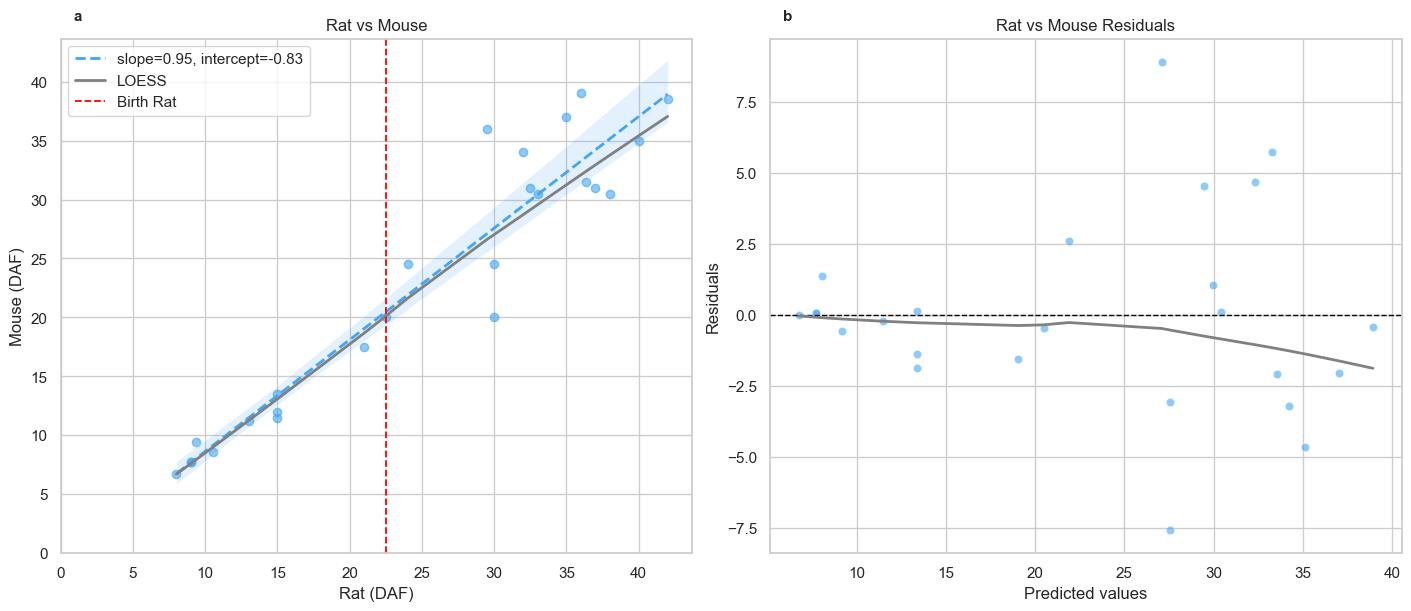

Panel saved as 'figures/panel4.tiff' and 'figures/panel4.pdf'


In [12]:
# Ultimo panel solamente: Rat vs Mouse (regression + residuals)
from matplotlib.lines import Line2D


def _add_panel_letters(ax, letter):
    ax.text(
        0.02,
        1.03,
        letter,
        transform=ax.transAxes,
        fontsize=11,
        fontweight='bold',
        ha='left',
        va='bottom',
    )


dat_rm = df_pivot[['Rat', 'Mouse']].dropna()
slope_rm, intercept_rm, _, _, _ = stats.linregress(dat_rm['Rat'], dat_rm['Mouse'])
smoothed_rm = sm.nonparametric.lowess(dat_rm['Mouse'], dat_rm['Rat'], frac=0.8)

fig_rm, axes_rm = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

sns.regplot(data=dat_rm, x='Rat', y='Mouse', color=colors['Mouse'],
            scatter_kws={'alpha': 0.6},
            line_kws={'linestyle': '--', 'linewidth': 2},
            ax=axes_rm[0])
axes_rm[0].plot(smoothed_rm[:, 0], smoothed_rm[:, 1], color='gray', linewidth=2)
axes_rm[0].axvline(x=rat_birth, color='red', linestyle='--', linewidth=1.3)
axes_rm[0].set_xlim(left=0)
axes_rm[0].set_ylim(bottom=0)
axes_rm[0].set_xlabel('Rat (DAF)')
axes_rm[0].set_ylabel('Mouse (DAF)')
axes_rm[0].set_title('Rat vs Mouse')
axes_rm[0].legend(handles=[
    Line2D([0], [0], color=colors['Mouse'], linestyle='--', linewidth=2,
           label=f'slope={slope_rm:.2f}, intercept={intercept_rm:.2f}'),
    Line2D([0], [0], color='gray', linestyle='-', linewidth=2, label='LOESS'),
    Line2D([0], [0], color='red', linestyle='--', linewidth=1.3, label='Birth Rat'),
])
_add_panel_letters(axes_rm[0], 'a')

x_rm = dat_rm['Rat'].values.astype(float)
y_rm = dat_rm['Mouse'].values.astype(float)
fitted_rm = slope_rm * x_rm + intercept_rm
resid_rm = y_rm - fitted_rm
sns.scatterplot(x=fitted_rm, y=resid_rm, color=colors['Mouse'], alpha=0.6, ax=axes_rm[1])
axes_rm[1].axhline(0, color='black', linestyle='--', linewidth=1)
loess_rm = sm.nonparametric.lowess(resid_rm, fitted_rm, frac=0.8)
axes_rm[1].plot(loess_rm[:, 0], loess_rm[:, 1], color='gray', linewidth=2)
axes_rm[1].set_xlabel('Predicted values')
axes_rm[1].set_ylabel('Residuals')
axes_rm[1].set_title('Rat vs Mouse Residuals')
_add_panel_letters(axes_rm[1], 'b')

# Evita problemas de fuentes en revistas/editoriales
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



# Guardar en PDF vectorial
plt.savefig(
    'figures/panel4.pdf',
    bbox_inches='tight'
)

# Guardar en TIFF alta resolución
plt.savefig(
    'figures/panel4.tiff',
    dpi=TIFF_DPI,
    bbox_inches='tight'
)
plt.show()

print("Panel saved as 'figures/panel4.tiff' and 'figures/panel4.pdf'")
plt.show()

In [13]:
# Regresion OLS (salida statsmodels)



# Usa x_rm e y_rm ya calculados en el notebook
x = np.asarray(x_rm, dtype=float)
y = np.asarray(y_rm, dtype=float)
mask = np.isfinite(x) & np.isfinite(y)

X = sm.add_constant(x[mask])
model = sm.OLS(y[mask], X).fit()

summary_text = model.summary().as_text()
print(summary_text)



                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.905
Method:                 Least Squares   F-statistic:                     230.9
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           1.75e-13
Time:                        12:38:26   Log-Likelihood:                -65.683
No. Observations:                  25   AIC:                             135.4
Df Residuals:                      23   BIC:                             137.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8297      1.702     -0.487      0.6

In [14]:
# Test de Breusch-Pagan (heterocedasticidad) sobre el modelo OLS Rat vs Mouse
bp_labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
bp_results = het_breuschpagan(model.resid, model.model.exog)
bp_dict = dict(zip(bp_labels, bp_results))

for label, value in bp_dict.items():
    print(f'{label}: {value:.4f}')

bp_p = bp_dict['LM-Test p-value']
print(f"\nInterpretacion: p {'<' if bp_p < 0.05 else '>='} 0.05 -> "
      f"{'heterocedasticidad significativa' if bp_p < 0.05 else 'sin evidencia de heterocedasticidad'}")






LM Statistic: 3.0201
LM-Test p-value: 0.0822
F-Statistic: 3.1603
F-Test p-value: 0.0887

Interpretacion: p >= 0.05 -> sin evidencia de heterocedasticidad
